In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt
import catboost as cb

import sys
sys.path.insert(0, '../..')

from sn_clf.scripts.utils import get_sn_label_from_akb, load_features, download_akb_json, plot_config, get_art_label_from_akb, convert_to_onnx

plot_config()

In [2]:
#Crossmatch ojects from BTS and OIDs file
oids, features = load_features('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/feature_snad_clf_r_100.dat')
bts_sn = pd.read_csv('../data/bts_crossmatched_2sec.csv')


#t = time.monotonic()
#bts_oids = list(bts_sn['OID'])
#crossmatch = np.isin(oids, bts_oids)
#print(f'Crossmatched in {np.round((time.monotonic() - t) / 60)} min')
#np.save(f'../data/bts_dr23_crossmatch.npy', crossmatch)

crossmatch = np.load(f'../data/bts_dr23_crossmatch.npy')

OSError: [Errno 12] Cannot allocate memory

In [3]:
#Choose features, which will be used in training process
feature_names = '../../dr23-features/feature_snad_clf_r_100.name'
with open(feature_names) as f:
    names = f.read().split()

In [4]:
akb_oid, art_label = get_art_label_from_akb(f'../data/akb_objects.json')

# t = time.monotonic()
# akb_crossmatch = np.isin(oids, akb_oid)
# print(f'Crossmatched in {np.round((time.monotonic() - t) / 60)} min')
# np.save(f'../data/akb_all_dr23_crossmatch.npy', akb_crossmatch)

akb_crossmatch = np.load(f'../data/akb_all_dr23_crossmatch.npy')    
akb_features = features[akb_crossmatch]



akb_features = pd.DataFrame(data=akb_features, columns=names)
akb_oids = oids[akb_crossmatch]
akb_art_lab = []
for oid in akb_oids:
    akb_art_lab.append(art_label[akb_oid == oid][0])
akb_art_lab = np.array(akb_art_lab)
akb_features['artefact'] = 1 - akb_art_lab
akb_features['oid'] = akb_oids

_, akb_sn_label = get_sn_label_from_akb('../data/akb_objects.json')
akb_sn_crossmatch = np.load(f'../data/akb_sn_dr23_crossmatch.npy')
akb_sn_oid = oids[akb_sn_crossmatch]
sn_mask = np.isin(akb_oids, akb_sn_oid)
is_sn = np.zeros(akb_oids.shape)
is_sn[sn_mask] = np.ones(is_sn[sn_mask].shape)

akb_features['is_sn'] = is_sn

In [5]:
akb_ot = np.zeros(len(akb_features))
akb_ot[(akb_features['artefact'] == 0) * (akb_features['is_sn'] == 0)] = np.ones(sum((akb_features['artefact'] == 0) * (akb_features['is_sn'] == 0)))
akb_features['akb_ot'] = akb_ot
akb_features['regular_obj'] = np.zeros(len(akb_features))

In [6]:

random_seed = 42

validated = pd.read_csv('bts_sample_oid.csv')
validated = validated[validated['is_sn'] == 1]['url'].apply(lambda url: url.split('/')[-1]).astype(np.uint64)

val_mask = np.isin(oids[crossmatch], validated)
bts_features = features[crossmatch][val_mask] # содержит только SN
bts_features = pd.DataFrame(data=bts_features, columns=names)
bts_features['oid'] = oids[crossmatch][val_mask]
bts_features['artefact'] = np.zeros(len(bts_features))
bts_features['is_sn'] = np.ones(len(bts_features))
bts_features['regular_obj'] = np.zeros(len(bts_features))
bts_features['akb_ot'] = np.zeros(len(bts_features))

# тут в качестве негативного класса используются рандомные объекты из дата релиза
indx = np.random.choice(np.arange(len(oids)), 10000)
regular_obj_feat = features[indx]
regular_obj_oid = oids[indx]
regular_obj = pd.DataFrame(data=regular_obj_feat, columns=names)
regular_obj['oid'] = regular_obj_oid
regular_obj['artefact'] = np.zeros(len(regular_obj))
regular_obj['is_sn'] = np.zeros(len(regular_obj))
regular_obj['akb_ot'] = np.zeros(len(regular_obj))
regular_obj['regular_obj'] = np.ones(len(regular_obj))
# train_data = np.vstack([bts_features, regular_obj[:len(bts_features)]])
# test_data = np.vstack([akb_sn_features, regular_obj[len(bts_features):]])

# train_labels = np.hstack([np.ones(len(bts_features)), np.zeros(len(bts_features))])
# test_labels = np.hstack([np.ones(len(akb_sn_features)), np.zeros(len(akb_sn_features))])


# тут в качестве негативного класса используются объекты из акб
# в выборках 10% артефактов


In [7]:
# train_size = len(bts_features) * 4 #SN -- 0.5,  artefact -- 0.1
# art_number_train = len(bts_features)

# #normal_obj_number = len(bts_features) - art_number_train - len(regular_obj_feat) #+ len(test_pos) - art_number_test

# artefacts = akb_features[(akb_features['artefact'] == 1)].sample(art_number_train, random_state=random_seed)
# akb_ot = akb_features[akb_features['akb_ot'] == 1].sample(len(bts_features), random_state=random_seed)
# train_data = pd.concat([bts_features, 
#                         akb_ot,
#                         artefacts,
#                         regular_obj])

train_data = pd.concat([bts_features, 
                        akb_features[akb_features['is_sn'] == 0], # все из акб кроме сн
                        regular_obj])
#test = pd.concat([test_pos, normal_obj.iloc[len(tns_features) - art_number_train:], artefacts.iloc[art_number_train:]])


print(f"Artefact fraction in train sample:{((train_data['artefact'] == 1).sum() / len(train_data)):.2f}")
#print(f"Artefact fraction in test sample:{((test['artefact'] == 1).sum() / len(test)):.2f}")

print(f"SN fraction in train sample:{((train_data['is_sn'] == 1).sum() / len(train_data)):.2f}")
#print(f"SN fraction in test sample:{((test['label'] == 1).sum() / len(test)):.2f}")
print(f"AKB other types fraction in train sample:{((train_data['akb_ot'] == 1).sum() / len(train_data)):.2f}")
print(f"regular object fraction in train sample:{((train_data['regular_obj'] == 1).sum() / len(train_data)):.2f}")

print(f'Train size: {len(train_data)}')

Artefact fraction in train sample:0.21
SN fraction in train sample:0.04
AKB other types fraction in train sample:0.16
regular object fraction in train sample:0.59
Train size: 16974


In [8]:
train_data['label'] = np.argmax(train_data[['artefact', 'is_sn', 'regular_obj', 'akb_ot']] .values, axis=1)

In [9]:
#train_data.to_csv('../data/train_data_big.csv', index=False)
train_data = pd.read_csv('../data/train_data_big.csv')

In [8]:
# Train and validate real-bogus model
random_seed = 42
print('Training model...')
t = time.monotonic()
model = RandomForestClassifier(random_state=random_seed, class_weight={0: 1, 1: 1e3})
#score_types = ('accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'roc_auc_ovr')
score_types = ('accuracy', 'f1','roc_auc')

result = cross_validate(model, train_data[names], train_data['is_sn'],
                        cv=KFold(shuffle=True, random_state=random_seed),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                        n_jobs=5
                       )

print('Scores for Random Forest Classifier:')
for score in score_types:
    mean = np.mean(result[f'test_{score}'])
    std = np.std(result[f'test_{score}'])
    print(f'{score} = {mean:.3f} +- {std:.3f}')
t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')
    
#assert np.mean(result['test_accuracy']) > 0.7, 'Accuracy for trained model is too low!'
clf = result['estimator'][0]

#model_name = 'SNclf_dr23_clear_sn_sample'
#convert_to_onnx(clf, len(names), name=model_name)

Training model...
Scores for Random Forest Classifier:
accuracy = 0.987 +- 0.001
f1 = 0.815 +- 0.015
roc_auc = 0.986 +- 0.005
RF trained (with cross-validation) in 0 m


In [11]:
train_pred = clf.predict_proba(train_data[names])
train_data['SN_clf_proba'] = train_pred[:, 1]

In [13]:
train_data.to_csv('../data/train_data_big.csv', index=False)

In [13]:
model_name = 'rf_classweight'
convert_to_onnx(clf, len(names), name=model_name)

/tmp/ipykernel_4832/2078752448.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


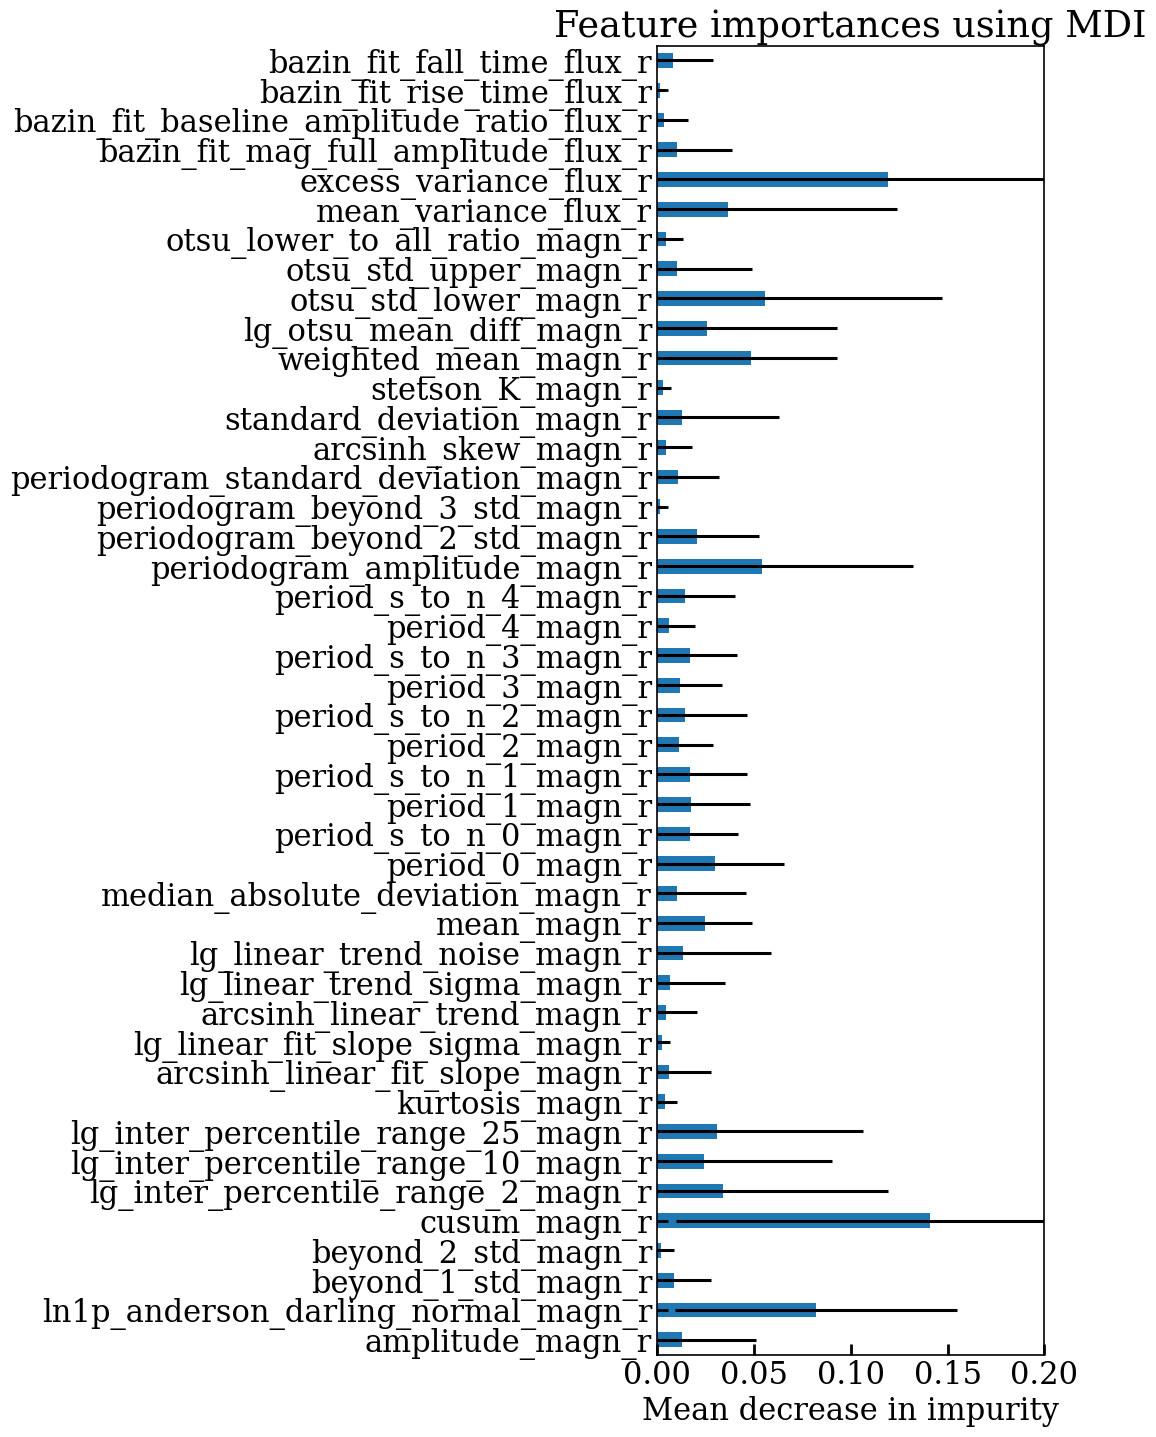

In [9]:
importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=names)

# fig, ax = plt.subplots(figsize=(15,5))
# forest_importances.plot.bar(yerr=std, ax=ax)
# ax.set_title("Feature importances using MDI")
# ax.set_ylabel("Mean decrease in impurity")
# plt.ylim(0, 0.2)
#fig.tight_layout()


fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

plt.savefig('feature_imp.png', bbox_inches='tight')

In [21]:
filtered = np.array([False if 'chi2' in str(item) else True for item in names])

In [22]:
# Train and validate real-bogus model
print('Training model...')
t = time.monotonic()
model = RandomForestClassifier(max_depth=18, n_estimators=831, random_state=random_seed)
score_types = ('accuracy', 'roc_auc', 'f1')

result = cross_validate(model, train_data[:, filtered], train_labels,
                        cv=KFold(shuffle=True, random_state=random_seed),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                        n_jobs=5
                       )

print('Scores for Random Forest Classifier:')
for score in score_types:
    mean = np.mean(result[f'test_{score}'])
    std = np.std(result[f'test_{score}'])
    print(f'{score} = {mean:.3f} +- {std:.3f}')
t = (time.monotonic() - t) / 60
print(f'RF trained (with cross-validation) in {t:.0f} m')
    
#assert np.mean(result['test_accuracy']) > 0.7, 'Accuracy for trained model is too low!'
clf = result['estimator'][0]

#convert_to_onnx(clf, len(names), name=model_name)

Training model...
Scores for Random Forest Classifier:
accuracy = 0.947 +- 0.006
roc_auc = 0.986 +- 0.003
f1 = 0.947 +- 0.005
RF trained (with cross-validation) in 0 m


In [23]:
test_pred = clf.predict_proba(test_data[:, filtered])
akb_roc_auc = metrics.roc_auc_score(test_labels, test_pred[:, 1])
akb_accuracy = clf.score(test_data[:, filtered], test_labels)
print('Results on test data (SN from akb):')
print(f'ROC-AUC = {akb_roc_auc:.3f}')
print(f'Accuracy = {akb_accuracy:.3f}')

Results on test data (SN from akb):
ROC-AUC = 0.996
Accuracy = 0.962


/tmp/ipykernel_1643/2806668747.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


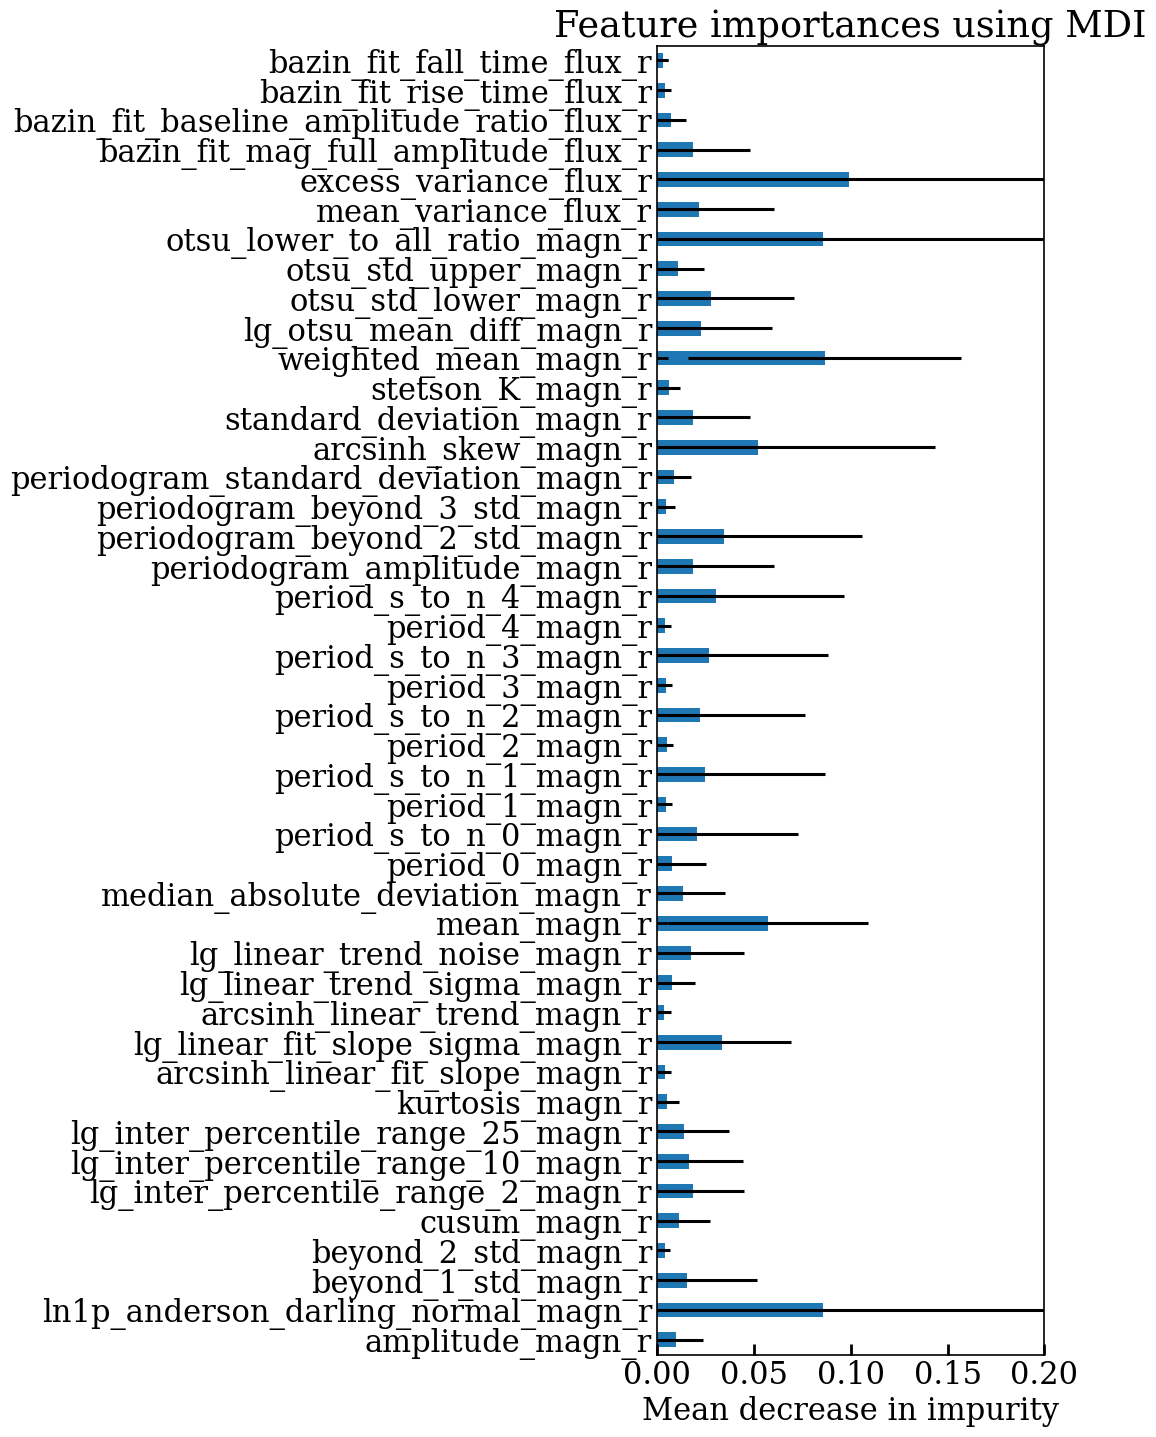

In [24]:
# importances = clf.feature_importances_
# std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

# forest_importances = pd.Series(importances, index=np.array(names)[filtered])

# fig, ax = plt.subplots(figsize=(17,5))
# forest_importances.plot.bar(yerr=std, ax=ax)
# ax.set_title("Feature importances using MDI")
# ax.set_ylabel("Mean decrease in impurity")
# plt.ylim(0, 0.2)
# fig.tight_layout()

importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=np.array(names)[filtered])

fig, ax = plt.subplots(figsize=(5,17))
# Используем barh вместо bar для горизонтальных столбцов
forest_importances.plot.barh(xerr=std, ax=ax)  # xerr вместо yerr для горизонтального графика
ax.set_title("Feature importances using MDI")
ax.set_xlabel("Mean decrease in impurity")  # Изменили ylabel на xlabel
plt.xlim(0, 0.2)  # Изменили ylim на xlim
fig.tight_layout()

plt.savefig('feature_imp_no-chi2.png', bbox_inches='tight')

(array([1717.,  381.,  208.,  121.,   85.,   50.,   53.,   31.,   18.,
          24.,   13.,   11.,    6.,    6.,    5.,    6.,    6.,    7.,
          19.,   14.,   27.,   22.,   34.,   34.,   54.,   61.,   72.,
         161.,  329., 1851.]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

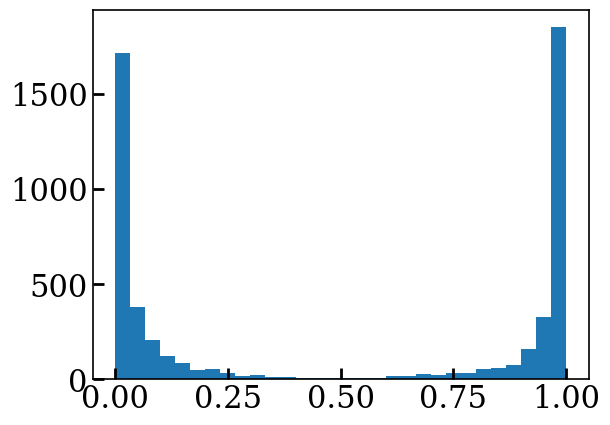

In [33]:
train_pred = clf.predict_proba(train_data[:, filtered])[:, 1]
plt.hist(train_pred, bins=30)

# CatBoost

In [14]:
params = {'objective': 'CrossEntropy',
 'colsample_bylevel': 0.06813255171984411,
 'depth': 7,
 'boosting_type': 'Plain',
 'bootstrap_type': 'Bayesian',
 'bagging_temperature': 1.5285913918433203}

In [15]:
rs=42

In [17]:
print('Training model...')
t = time.monotonic()
model = cb.CatBoostClassifier(**params, random_state=rs, verbose=0)
score_types = ('accuracy', 'roc_auc')

result = cross_validate(model, train_data[names], train_data[['is_sn', 'regular_obj', 'akb_ot', 'artefact']],
                        cv=KFold(shuffle=True, random_state=rs),
                        scoring=score_types,
                        return_estimator=True,
                        return_train_score=True,
                       )

print('Scores for CatBoost Classifier:')
for score in score_types:
    mean = np.mean(result[f'test_{score}'])
    std = np.std(result[f'test_{score}'])
    print(f'{score} = {mean:.2f} +- {std:.2f}')
t = (time.monotonic() - t) / 60
print(f'CatBoost trained (with cross-validation) in {t:.0f} m')

Training model...


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/workplace/anomaly_venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/workplace/anomaly_venv/lib/python3.12/site-packages/catboost/core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "/workplace/anomaly_venv/lib/python3.12/site-packages/catboost/core.py", line 2410, in _fit
    self._train(
  File "/workplace/anomaly_venv/lib/python3.12/site-packages/catboost/core.py", line 1790, in _train
    sel